# Bank Customer Churn: Logistic Regression and LightGBM (final notebook)

## How to run this (read first)
1. Open **https://colab.research.google.com** and choose **File > Upload notebook**. Pick this file.
2. Get these two files from your group repo (`results/outputs/` folder):
   - `final_train_processed.csv` (used for **training**)
   - `final_test_processed.csv` (1,914 rows, used **only once at the end** for testing)
3. Click **Runtime > Run all**. When the upload box appears (Step 1), select **both** files together.
4. Wait for the tuning cells (Step 3) to finish. This takes a few minutes.
5. At the end, four files download automatically. Give `LogisticRegression_final_result.csv` and `LightGBM_final_result.csv` to the group member who builds the comparison table.

**If something fails:** run the cells one at a time from the top. If you see "file not found", re-run the Step 1 upload cell and select both files.

## What this notebook does, in plain words
| Step | What | Why |
|---|---|---|
| 1 | Load the files, remove duplicate rows from train | The train file was oversampled, so it has copies. Copies would fool cross-validation. |
| 2 | Helper functions | One function scores any model, using that model's own predictions |
| 3 | Tune Logistic Regression and LightGBM with cross-validation | Finds the best settings using train data only. Oversampling is redone safely inside each fold |
| 4 | Test once on the 1,914-row file | An honest score on customers the models never saw |
| 5 | Plots | Confusion matrices, ROC curves, important features |
| 6 | Save results | Files for the group comparison |

**Golden rule:** the test file is never used for training or for choosing settings.

In [1]:
!pip install -q lightgbm imbalanced-learn

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, RocCurveDisplay)
from imblearn.pipeline import Pipeline            # NOT sklearn's Pipeline: this one allows oversampling inside it
from imblearn.over_sampling import RandomOverSampler
import lightgbm as lgb

SEED = 42

## Step 1. Load the group's files
- The train file was oversampled, so it contains exact duplicate rows (12,282 rows, only 7,654 unique).
- We drop the duplicates. Otherwise cross-validation would put copies of the same customer on both sides and the scores would be too high. Oversampling is redone safely *inside* each fold (Step 3).
- The test file is left untouched.

In [4]:
import os

try:
    from google.colab import files
    uploaded = files.upload()      # select final_train_processed.csv AND final_test_processed.csv
except ImportError:
    pass

# Helper to find the correct file path even if Colab renamed it with (1), (2), etc.
def find_file(base_name):
    if os.path.exists(base_name):
        return base_name
    # Search for renamed versions in the current directory
    name, ext = os.path.splitext(base_name)
    for f in os.listdir("."):
        if f.startswith(name) and f.endswith(ext):
            return f
    raise FileNotFoundError(f"Could not find {base_name} or any numbered variant of it.")

train_path = find_file("final_train_processed.csv")
test_path = find_file("final_test_processed.csv")

print(f"Loading train from: {train_path}")
print(f"Loading test from: {test_path}")

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)
print("Train before dedupe:", train_df.shape)
train_df = train_df.drop_duplicates().reset_index(drop=True)
print("Train after dedupe :", train_df.shape, train_df["Exited"].value_counts().to_dict())
print("Test (untouched)   :", test_df.shape,  test_df["Exited"].value_counts().to_dict())

ENGINEERED    = ["BalanceSalaryRatio", "TenureByAge", "BalancePerProduct",
                 "ProductsPerTenure", "ActiveWithCard", "IsZeroBalance"]
ALL_FEATURES  = [c for c in train_df.columns if c != "Exited"]
BASE_FEATURES = [c for c in ALL_FEATURES if c not in ENGINEERED]
y_train, y_test = train_df["Exited"], test_df["Exited"]
print(len(BASE_FEATURES), "base features;", len(ALL_FEATURES), "with engineered features")
SEED = 42

Saving final_test_processed (1).csv to final_test_processed (1) (1).csv
Saving final_train_processed (1).csv to final_train_processed (1) (1).csv
Loading train from: final_train_processed (1).csv
Loading test from: final_test_processed (1) (1).csv
Train before dedupe: (12282, 18)
Train after dedupe : (7654, 18) {0: 6141, 1: 1513}
Test (untouched)   : (1914, 18) {0: 1536, 1: 378}
11 base features; 17 with engineered features


## Step 7. Helper functions
`evaluate` computes all five metrics from the model's **own** predictions. It takes the model as an argument, so one model's predictions can never leak into another's results (the bug in the old notebook).

In [5]:
def evaluate(name, model, X, y):
    pred = model.predict(X)
    prob = model.predict_proba(X)[:, 1]          # AUC needs probabilities, not labels
    return {"Model": name,
            "Accuracy":  accuracy_score(y, pred),
            "Precision": precision_score(y, pred, zero_division=0),
            "Recall":    recall_score(y, pred, zero_division=0),
            "F1_Score":  f1_score(y, pred, zero_division=0),
            "ROC_AUC":   roc_auc_score(y, prob)}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def make_pipe(clf):
    # scaler and oversampler are fitted INSIDE each cross-validation fold -> no leakage
    return Pipeline([("scale", StandardScaler()),
                     ("oversample", RandomOverSampler(random_state=SEED)),
                     ("clf", clf)])

## Step 8. Tune and train several varieties
Rubric: *different pre-processing and hyperparameter tune-ups*. We create varieties by changing:
- **Pre-processing:** base features only vs. base + engineered features
- **Hyperparameters:** a grid searched with 5-fold stratified cross-validation, scored by ROC-AUC

Selection uses **cross-validation on training data only**, never the test set.

### 8A. Logistic Regression varieties

In [6]:
lr_grid = {"clf__C": [0.01, 0.1, 1, 10], "clf__penalty": ["l1", "l2"]}
lr_results, lr_models = [], {}

for label, feats in [("LR | base features", BASE_FEATURES), ("LR | + engineered features", ALL_FEATURES)]:
    gs = GridSearchCV(make_pipe(LogisticRegression(solver="liblinear", max_iter=1000, random_state=SEED)),
                      lr_grid, scoring="roc_auc", cv=cv, n_jobs=-1)
    gs.fit(train_df[feats], y_train)
    lr_models[label] = (gs, feats)
    print(f"{label}: best {gs.best_params_}  CV AUC = {gs.best_score_:.4f}")

LR | base features: best {'clf__C': 0.01, 'clf__penalty': 'l1'}  CV AUC = 0.7914
LR | + engineered features: best {'clf__C': 0.1, 'clf__penalty': 'l2'}  CV AUC = 0.7916


### 8B. LightGBM varieties
`subsample_freq=1` is required, otherwise `subsample` is silently ignored.

In [7]:
lgb_grid = {"clf__n_estimators": [100, 200, 300],
            "clf__max_depth": [3, 5, 7],
            "clf__learning_rate": [0.03, 0.1],
            "clf__num_leaves": [15, 31]}
lgb_models = {}

for label, feats in [("LightGBM | base features", BASE_FEATURES), ("LightGBM | + engineered features", ALL_FEATURES)]:
    gs = GridSearchCV(make_pipe(lgb.LGBMClassifier(subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                                                   random_state=SEED, verbosity=-1)),
                      lgb_grid, scoring="roc_auc", cv=cv, n_jobs=-1)
    gs.fit(train_df[feats], y_train)
    lgb_models[label] = (gs, feats)
    print(f"{label}: best {gs.best_params_}  CV AUC = {gs.best_score_:.4f}")

LightGBM | base features: best {'clf__learning_rate': 0.03, 'clf__max_depth': 7, 'clf__n_estimators': 200, 'clf__num_leaves': 15}  CV AUC = 0.8574
LightGBM | + engineered features: best {'clf__learning_rate': 0.03, 'clf__max_depth': 3, 'clf__n_estimators': 300, 'clf__num_leaves': 15}  CV AUC = 0.8565


## Step 9. Evaluate on the test set (once)
Now the locked test set is opened. Each variety is scored with its own predictions.
Pick the winner by **cross-validation** score (Step 8), not by peeking at these numbers.

In [8]:
rows = []
for label, (gs, feats) in {**lr_models, **lgb_models}.items():
    r = evaluate(label, gs, test_df[feats], y_test)
    r["CV_AUC (train)"] = gs.best_score_
    rows.append(r)

results = pd.DataFrame(rows).round(4)
results

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,CV_AUC (train)
0,LR | base features,0.7173,0.3821,0.6984,0.4939,0.7851,0.7914
1,LR | + engineered features,0.7351,0.3991,0.6746,0.5015,0.7849,0.7916
2,LightGBM | base features,0.8093,0.5123,0.7169,0.5976,0.8633,0.8574
3,LightGBM | + engineered features,0.8119,0.5170,0.7249,0.6035,0.8643,0.8565


In [9]:
best_lr_label  = max(lr_models,  key=lambda k: lr_models[k][0].best_score_)
best_lgb_label = max(lgb_models, key=lambda k: lgb_models[k][0].best_score_)
best_lr,  lr_feats  = lr_models[best_lr_label]
best_lgb, lgb_feats = lgb_models[best_lgb_label]
print("Best Logistic Regression variety:", best_lr_label)
print("Best LightGBM variety           :", best_lgb_label)

for name, model, feats in [("Logistic Regression", best_lr, lr_feats), ("LightGBM", best_lgb, lgb_feats)]:
    print("\n=====", name, "=====")
    print(classification_report(y_test, model.predict(test_df[feats]), target_names=["Retained", "Churned"]))
    print("Confusion matrix:\n", confusion_matrix(y_test, model.predict(test_df[feats])))

Best Logistic Regression variety: LR | + engineered features
Best LightGBM variety           : LightGBM | base features

===== Logistic Regression =====
              precision    recall  f1-score   support

    Retained       0.90      0.75      0.82      1536
     Churned       0.40      0.67      0.50       378

    accuracy                           0.74      1914
   macro avg       0.65      0.71      0.66      1914
weighted avg       0.80      0.74      0.76      1914

Confusion matrix:
 [[1152  384]
 [ 123  255]]

===== LightGBM =====
              precision    recall  f1-score   support

    Retained       0.92      0.83      0.88      1536
     Churned       0.51      0.72      0.60       378

    accuracy                           0.81      1914
   macro avg       0.72      0.77      0.74      1914
weighted avg       0.84      0.81      0.82      1914

Confusion matrix:
 [[1278  258]
 [ 107  271]]


## Step 10. Plots for your viva: confusion matrices and ROC curves

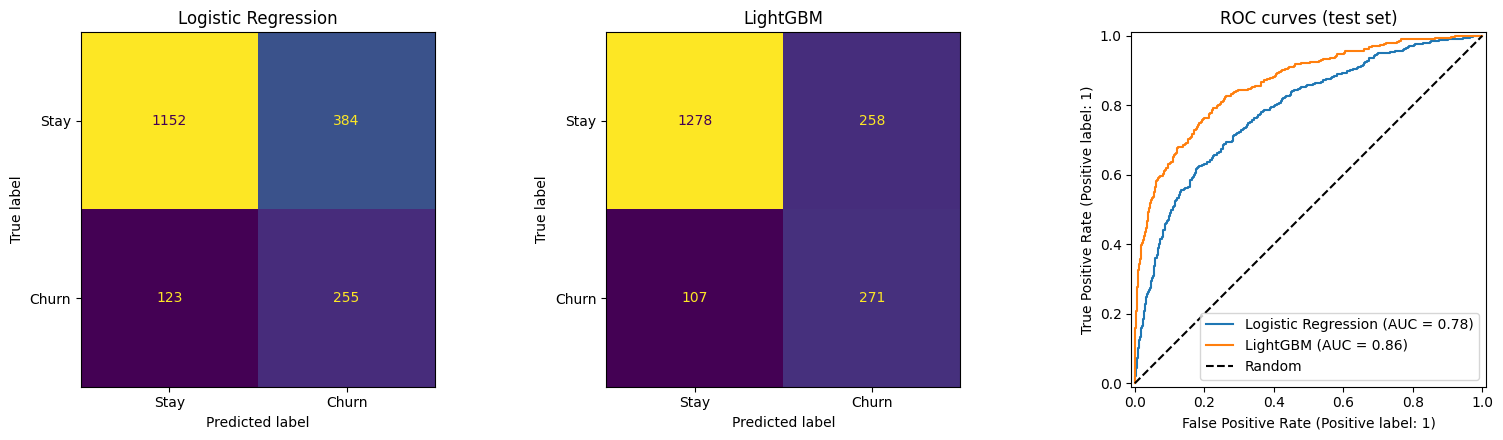

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
for a, (name, model, feats) in zip(ax[:2], [("Logistic Regression", best_lr, lr_feats), ("LightGBM", best_lgb, lgb_feats)]):
    ConfusionMatrixDisplay.from_estimator(model, test_df[feats], y_test, display_labels=["Stay", "Churn"], ax=a, colorbar=False)
    a.set_title(name)
RocCurveDisplay.from_estimator(best_lr,  test_df[lr_feats],  y_test, name="Logistic Regression", ax=ax[2])
RocCurveDisplay.from_estimator(best_lgb, test_df[lgb_feats], y_test, name="LightGBM", ax=ax[2])
ax[2].plot([0, 1], [0, 1], "k--", label="Random"); ax[2].legend(); ax[2].set_title("ROC curves (test set)")
plt.tight_layout(); plt.show()

### Which features matter?

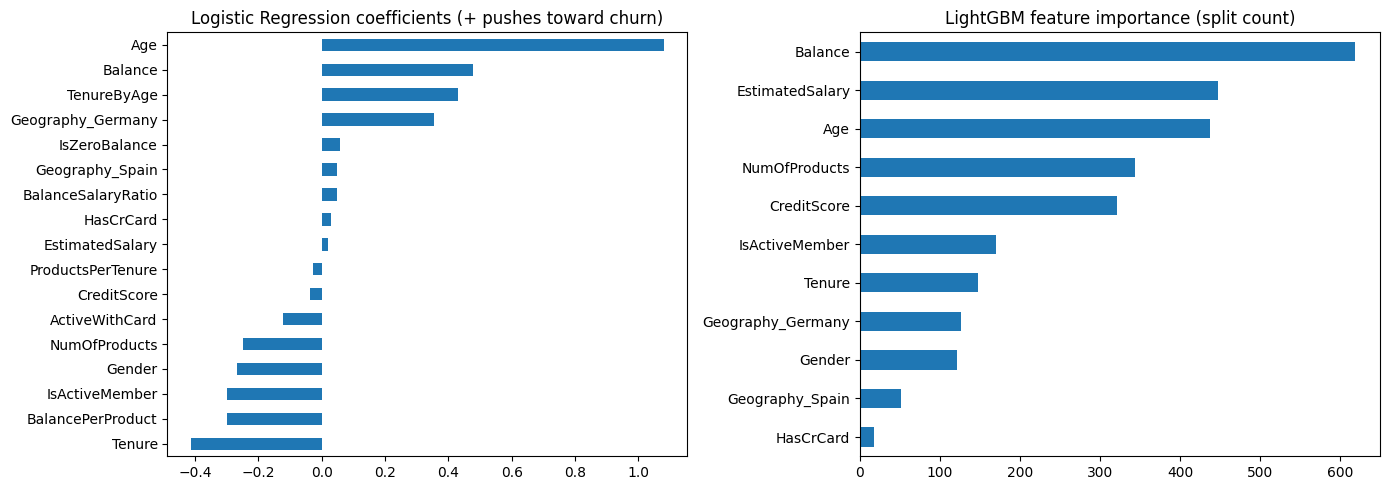

In [11]:
coefs = pd.Series(best_lr.best_estimator_.named_steps["clf"].coef_[0], index=lr_feats).sort_values()
imp = pd.Series(best_lgb.best_estimator_.named_steps["clf"].feature_importances_, index=lgb_feats).sort_values()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
coefs.plot.barh(ax=ax[0], title="Logistic Regression coefficients (+ pushes toward churn)")
imp.plot.barh(ax=ax[1], title="LightGBM feature importance (split count)")
plt.tight_layout(); plt.show()

## Step 11. Save the final results for the group comparison
One row per model, with columns `Model, Accuracy, Precision, Recall, F1_Score, ROC_AUC`.
Each file is built from its **own** model, so the two files can never be identical by accident.

In [13]:
lr_final   = pd.DataFrame([evaluate("Logistic Regression", best_lr,  test_df[lr_feats],  y_test)])
lgb_final  = pd.DataFrame([evaluate("LightGBM",             best_lgb, test_df[lgb_feats], y_test)])

lr_final.to_csv("LogisticRegression_final_result.csv", index=False)
lgb_final.to_csv("LightGBM_final_result.csv", index=False)
results.to_csv("LR_LightGBM_all_varieties.csv", index=False)

display(pd.concat([lr_final, lgb_final]).round(4))
assert not lr_final.round(6).equals(lgb_final.drop(columns="Model").assign(Model="Logistic Regression").round(6)), \
    "Results are identical: something is wrong"

try:
    from google.colab import files
    for f in ["LogisticRegression_final_result.csv", "LightGBM_final_result.csv",
              "LR_LightGBM_all_varieties.csv"]:
        files.download(f)
except ImportError:
    pass

,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Logistic Regression,0.7351,0.3991,0.6746,0.5015,0.7849
0,LightGBM,0.8093,0.5123,0.7169,0.5976,0.8633


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Checklist: the mistakes this notebook avoids
| Mistake | Fix used here |
|---|---|
| Oversampling before splitting (duplicates in test) | Duplicates removed from train; oversample only inside CV folds |
| Scaling or outlier limits fitted on all data | Outlier limits from train; scaler fitted inside the pipeline |
| Models tested on different test sets | The group's shared `final_test_processed.csv` |
| Reusing `y_pred` variables between models | `evaluate(name, model, X, y)` uses each model's own predictions |
| Choosing the model by looking at test scores | Selection by cross-validation AUC on train |
| `subsample` ignored in LightGBM | `subsample_freq=1` set |
| Only one fixed configuration | GridSearchCV plus two preprocessing varieties per model |
| Optimistic CV from duplicated rows | Oversampling happens inside each fold, after the fold split |

## Things to say in the viva
- **Why these two models:** Logistic Regression is the interpretable baseline; LightGBM is a strong boosted-tree model.
- **Validation method:** stratified 5-fold CV on train for selection, one hold-out test set for the final score.
- **Main metric:** ROC-AUC, with recall and precision for the business trade-off.
- **Limitations:** single hold-out split; random oversampling duplicates rows; default 0.5 threshold; no SHAP.
- **Improvements:** threshold tuning, SMOTE, early stopping, SHAP, repeated CV.

## Viva notes: what to say about this notebook
**Why these models?** Logistic Regression is the simple, interpretable baseline. LightGBM is a boosted-tree model that captures non-linear patterns.

**Preprocessing varieties (rubric):** base features only vs. base plus 6 engineered features, for each model.

**Tuning method:** GridSearchCV, 5-fold stratified cross-validation, scored by ROC-AUC.
- Logistic Regression grid: C in {0.01, 0.1, 1, 10}, penalty in {l1, l2}.
- LightGBM grid: n_estimators {100, 200, 300}, max_depth {3, 5, 7}, learning_rate {0.03, 0.1}, num_leaves {15, 31}.

**Validation method:** cross-validation on train for choosing settings; one hold-out test file for the final score.

**Why these metrics:** ROC-AUC is the main metric (threshold-free, robust to imbalance). Recall shows how many churners were caught, precision shows how many alerts were correct, F1 balances them. Accuracy alone misleads because 80% of customers stay.

**Comparison and conclusion:** state the table from Step 4. LightGBM scores clearly higher than Logistic Regression on ROC-AUC and precision, so non-linear patterns matter. Also say which variety won and that the engineered features gave little or no gain.

**Limitations:** one hold-out split; random oversampling copies rows; default 0.5 threshold; outliers and scaling in the group files were computed on all data before the split (a mild leak); no SHAP.

**Improvements:** tune the decision threshold for higher recall, try SMOTE, add early stopping, use SHAP, repeat cross-validation.

**Be ready to show:** Step 1 output (duplicates removed), Step 3 best parameters, the Step 4 results table, the confusion matrices and ROC curves, and the final CSV files.